# Explaination of the logistics function as we use it

In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [2]:
fitParams = {
    "a": 3,    # start
    "L": -2,   # range
    "k": 0.5,  # rate
    "x0": 10   # midpoint
}
fitParams

{'a': 3, 'L': -2, 'k': 0.5, 'x0': 10}

In [3]:
def logistics(x, p):
    return p['a'] + p['L']/(1+np.exp(-p['k']*(x-p['x0'])))

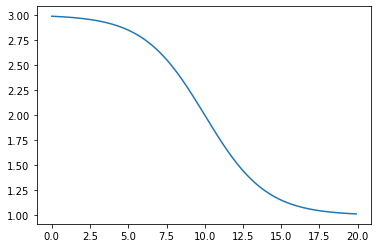

In [4]:
t = np.arange(0,20,0.1)
I = logistics(t,fitParams)
plt.plot(t,I)

# Let's do some math
$\frac{d}{dx} \frac{L}{1+e^{-k(x-x_0)}}$ at $x = x_0 $ is $ \frac{kL}{4}$

So the rate of change of the logistics function around the midpoint of the curve is equal to $\frac{kL}{4}$ This is the amount of nanoseconds of decrease in 1 second.

'kL/4 = -0.25ns change per second'

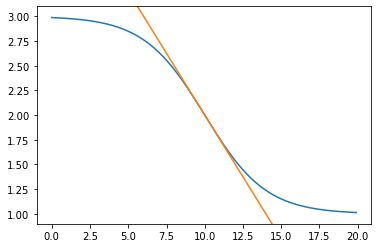

In [5]:
plt.plot(t,I,t,fitParams['a']+fitParams['L']/2+(t-fitParams['x0'])*fitParams['k']*fitParams['L']/4)
plt.ylim([.9,3.1])
f"kL/4 = {fitParams['k']*fitParams['L']/4}ns change per second"

This means $\frac{4}{kL}$ is the amount of seconds required for a nanosecond change. 

$\frac{4}{k}$ is the amount of seconds for L nanoseconds of change. The entire range.

In [6]:
f"4/k = {4/fitParams['k']}seconds"

'4/k = 8.0seconds'

# Therefore we report 4/k as the break down time.

(0.9, 3.1)

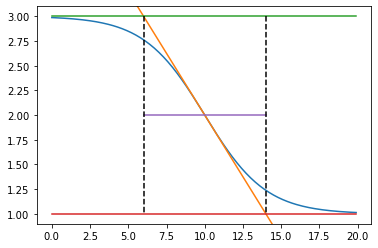

In [7]:
plt.plot(t,I,t,fitParams['a']+fitParams['L']/2+(t-10)*fitParams['k']*fitParams['L']/4)
plt.plot(t,np.repeat(fitParams['a'],len(t)))
plt.plot(t,np.repeat(fitParams['a']+fitParams['L'],len(t)))
bdt = 4/fitParams['k']  # break down time
plt.plot([fitParams["x0"]-bdt/2,fitParams["x0"]+bdt/2],[(fitParams['a']+fitParams['L']/2),(fitParams['a']+fitParams['L']/2)])
plt.plot([fitParams["x0"]-bdt/2,fitParams["x0"]-bdt/2],[fitParams['a'],fitParams['a']+fitParams['L']],'k--')
plt.plot([fitParams["x0"]+bdt/2,fitParams["x0"]+bdt/2],[fitParams['a'],fitParams['a']+fitParams['L']],'k--')
plt.ylim([.9,3.1])

The purple line has the length of the break down time

Accidentally we reported half-time(s) before, which was $ln(2)/k$. So to go from one to the other we have to $*4$ and $/ln(2)$

# what is the percentage of decay in the purple line?

If we fill in for x = x_0 - 2/k we get a+L/(1+e**2)

If we fill in for x = x_0 + 2/k we get a+L/(1+e**-2)

In [8]:
1/(1+np.exp(-2)) - 1/(1+np.exp(2))

0.7615941559557647

So the range is 76%